<a href="https://colab.research.google.com/github/zzzzzssyy/ECON3916-33674-Statistical-Machine-Learning/blob/main/Assignment%205/Assignment_5_The_Sovereign_Risk_Engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install wbgapi scikit-learn statsmodels matplotlib seaborn numpy pandas

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, Lasso, LassoCV, lasso_path
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, Lasso, LassoCV, lasso_path, LogisticRegression
from sklearn.metrics import (mean_squared_error, r2_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    roc_curve, roc_auc_score, precision_recall_curve, average_precision_score,
    f1_score, precision_score, recall_score)

import wbgapi as wb

np.random.seed(42)

print("Setup Finished")


Setup Finished


In [10]:
import wbgapi as wb
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

INDICATORS = {
    'NY.GDP.PCAP.KD.ZG': 'gdp_growth_pc',

    'NE.TRD.GNFS.ZS':    'trade_pct_gdp',
    'BX.KLT.DINV.WD.GD.ZS': 'fdi_inflows_pct_gdp',
    'TM.TAX.MRCH.SM.AR.ZS': 'tariff_rate_avg',
    'BX.GSR.ROYL.CD':    'royalties_receipts',

    'FP.CPI.TOTL.ZG':    'inflation_cpi',
    'GC.DOD.TOTL.GD.ZS': 'govt_debt_pct_gdp',
    'GC.XPN.TOTL.GD.ZS': 'govt_expenditure_pct_gdp',
    'BN.CAB.XOKA.GD.ZS': 'current_account_pct_gdp',
    'FR.INR.RINR':        'real_interest_rate',
    'PA.NUS.FCRF':        'exchange_rate_official',

    'SE.SEC.ENRR':        'secondary_enrollment_gross',
    'SE.TER.ENRR':        'tertiary_enrollment_gross',
    'SE.ADT.LITR.ZS':    'adult_literacy_rate',
    'SE.XPD.TOTL.GD.ZS': 'education_expenditure_pct_gdp',
    'SL.UEM.TOTL.ZS':    'unemployment_rate',

    'IT.NET.USER.ZS':     'internet_users_pct',
    'IT.CEL.SETS.P2':     'mobile_subscriptions_per100',
    'EG.ELC.ACCS.ZS':    'electricity_access_pct',
    'IS.ROD.PAVE.ZS':    'paved_roads_pct',

    'SP.DYN.LE00.IN':     'life_expectancy',
    'SH.DYN.MORT':        'infant_mortality_per1000',
    'SP.POP.GROW':        'population_growth',
    'SP.URB.TOTL.IN.ZS': 'urbanization_pct',
    'SH.XPD.CHEX.GD.ZS': 'health_expenditure_pct_gdp',

    'FS.AST.DOMS.GD.ZS': 'domestic_credit_pct_gdp',
    'CM.MKT.LCAP.GD.ZS': 'market_cap_pct_gdp',
    'FB.ATM.TOTL.P5':     'atms_per100k',
    'FD.AST.PRVT.GD.ZS': 'private_credit_pct_gdp',

    'NY.GDP.TOTL.RT.ZS': 'natural_resource_rents_pct_gdp',
    'EG.FEC.RNEW.ZS':    'renewable_energy_pct',
    'EN.ATM.CO2E.PC':    'co2_emissions_per_capita',

    'NV.AGR.TOTL.ZS':    'agriculture_pct_gdp',
    'AG.LND.ARBL.ZS':    'arable_land_pct',

    'IQ.CPA.TRAD.XQ':    'trade_cpia',
    'IQ.CPA.FINS.XQ':    'financial_management_cpia',
    'IQ.CPA.PROP.XQ':    'property_rights_cpia',
}

OUTCOME_VAR = 'gdp_growth_pc'
indicator_list = list(INDICATORS.keys())

print(f"Downloading {len(indicator_list)} indicators for all countries during 2013-2019")

try:
    raw_data = wb.data.DataFrame(
        indicator_list,
        time=range(2013, 2020),
        skipBlanks=True,
        labels=False
    )
    print(f"Raw data shape: {raw_data.shape}")
    print("Download successful ✓")
except Exception as e:
    print(f"API error: {e}")
    print("Loading fallback data from CSV...")

Raw data shape: (7211, 7)
Download successful ✓


In [58]:
if isinstance(raw_data.index, pd.MultiIndex):
    indicator_yearly_avg = raw_data.mean(axis=1)
    df_mean = indicator_yearly_avg.unstack(level='series')
else:
    df_mean = raw_data.copy()

df_mean = df_mean.rename(columns=INDICATORS)

min_cols = int(0.6 * len(df_mean.columns))
df_clean = df_mean.dropna(thresh=min_cols, axis=0)

min_rows = int(0.6 * len(df_clean))
df_clean = df_clean.dropna(thresh=min_rows, axis=1)

df_clean = df_clean.fillna(df_clean.median(numeric_only=True))

print(f"After cleaning — shape: {df_clean.shape}")
print(f"Countries retained: {len(df_clean)}")
print(f"Indicators retained: {len(df_clean.columns)}")

After cleaning — shape: (238, 29)
Countries retained: 238
Indicators retained: 29


In [18]:
df_clean['crisis'] = (df_clean[OUTCOME_VAR] < 0).astype(int)

feature_cols = [c for c in df_clean.columns if c not in [OUTCOME_VAR, 'crisis']]

X = df_clean[feature_cols]
y_reg = df_clean[OUTCOME_VAR]
y_cls = df_clean['crisis']

X_train, X_test, \
y_reg_train, y_reg_test, \
y_cls_train, y_cls_test = train_test_split(
    X, y_reg, y_cls,
    test_size=0.3,
    random_state=42
)

scaler = StandardScaler()
X_train_sc = pd.DataFrame(
scaler.fit_transform(X_train),
    columns=feature_cols,
    index=X_train.index
)
X_test_sc = pd.DataFrame(
    scaler.transform(X_test),
    columns=feature_cols,
    index=X_test.index
)

n_crisis = y_cls.sum()
n_total = len(y_cls)
base_rate = n_crisis / n_total

print(f"  FINAL DATASET SUMMARY")
print(f"  -------------------------------")
print(f"  Dataset dimensions : {df_clean.shape}")
print(f"  Number of features : {len(feature_cols)}")
print(f"  Train size         : {len(X_train)}")
print(f"  Test size          : {len(X_test)}")
print(f"  Crisis countries   : {n_crisis} / {n_total}")
print(f"  Crisis base rate   : {base_rate:.1%}")

  FINAL DATASET SUMMARY
  -------------------------------
  Dataset dimensions : (238, 30)
  Number of features : 28
  Train size         : 166
  Test size          : 72
  Crisis countries   : 38 / 238
  Crisis base rate   : 16.0%


Phase 1

In [23]:
ols = LinearRegression()
ols.fit(X_train_sc, y_reg_train)

r2_train_ols = ols.score(X_train_sc, y_reg_train)
r2_test_ols = ols.score(X_test_sc,  y_reg_test)
gap_ols = r2_train_ols - r2_test_ols

p = X_train_sc.shape[1]
n = X_train_sc.shape[0]
pn_ratio = p / n

print(f"OLS RESULTS")
print(f"------------------------")
print(f"Training R2 : {r2_train_ols:.4f}")
print(f"Test R2 : {r2_test_ols:.4f}")
print(f"Train-Test Gap : {gap_ols:.4f}")
print(f"p (predictors) : {p}")
print(f"n (observations) : {n}")
print(f"p/n ratio : {pn_ratio:.3f}")

  OLS RESULTS
  ------------------------
  Training R²  : 0.6034
  Test R²      : -0.9141
  Train-Test Gap : 1.5175
  p (predictors) : 28
  n (observations): 166
  p/n ratio      : 0.169


The high p/n ratio means OLS has too many predictors relative to observations, leaving almost no degrees of freedom to estimate true patterns. This forces the model to fit noise in the training data, producing high variance， near-perfect training R2 but poor test R².

In [25]:
alphas = np.logspace(-3, 4, 100)

ridge_cv = RidgeCV(alphas=alphas, cv=5)
ridge_cv.fit(X_train_sc, y_reg_train)

r2_train_ridge = ridge_cv.score(X_train_sc, y_reg_train)
r2_test_ridge = ridge_cv.score(X_test_sc,  y_reg_test)
n_nonzero_ridge = np.sum(np.abs(ridge_cv.coef_) > 1e-6)

lasso_cv = LassoCV(alphas=alphas, cv=5, max_iter=10000, random_state=42)
lasso_cv.fit(X_train_sc, y_reg_train)

r2_train_lasso = lasso_cv.score(X_train_sc, y_reg_train)
r2_test_lasso = lasso_cv.score(X_test_sc,  y_reg_test)
n_nonzero_lasso = np.sum(np.abs(lasso_cv.coef_) > 1e-6)

rmse_ols = np.sqrt(np.mean((ols.predict(X_test_sc)      - y_reg_test)**2))
rmse_ridge = np.sqrt(np.mean((ridge_cv.predict(X_test_sc) - y_reg_test)**2))
rmse_lasso = np.sqrt(np.mean((lasso_cv.predict(X_test_sc) - y_reg_test)**2))

comparison_table = pd.DataFrame({
    'Model':               ['OLS', 'Ridge', 'Lasso'],
    'Optimal Alpha':       ['-', f"{ridge_cv.alpha_:.4f}", f"{lasso_cv.alpha_:.4f}"],
    'Non-zero Predictors': [p, n_nonzero_ridge, n_nonzero_lasso],
    'Train R2':            [f"{r2_train_ols:.4f}", f"{r2_train_ridge:.4f}", f"{r2_train_lasso:.4f}"],
    'Test R2':             [f"{r2_test_ols:.4f}",  f"{r2_test_ridge:.4f}",  f"{r2_test_lasso:.4f}"],
    'Test RMSE':           [f"{rmse_ols:.4f}", f"{rmse_ridge:.4f}", f"{rmse_lasso:.4f}"],
})
comparison_table = comparison_table.set_index('Model')
print(comparison_table.to_string())

      Optimal Alpha  Non-zero Predictors Train R2  Test R2 Test RMSE
Model                                                               
OLS               -                   28   0.6034  -0.9141    2.9227
Ridge       46.4159                   28   0.5601  -0.0726    2.1879
Lasso        0.0689                   16   0.5719  -0.3428    2.4479


I recommend Lasso  for IMF operational GDP growth forecasting, because it zeros out irrelevant predictors entirely, producing a sparse and interpretable model suited for IMF operational use. Ridge reduces variance by shrinking all coefficients uniformly, while Lasso sacrifices more bias to achieve sparsity a better tradeoff when interpretability matters.

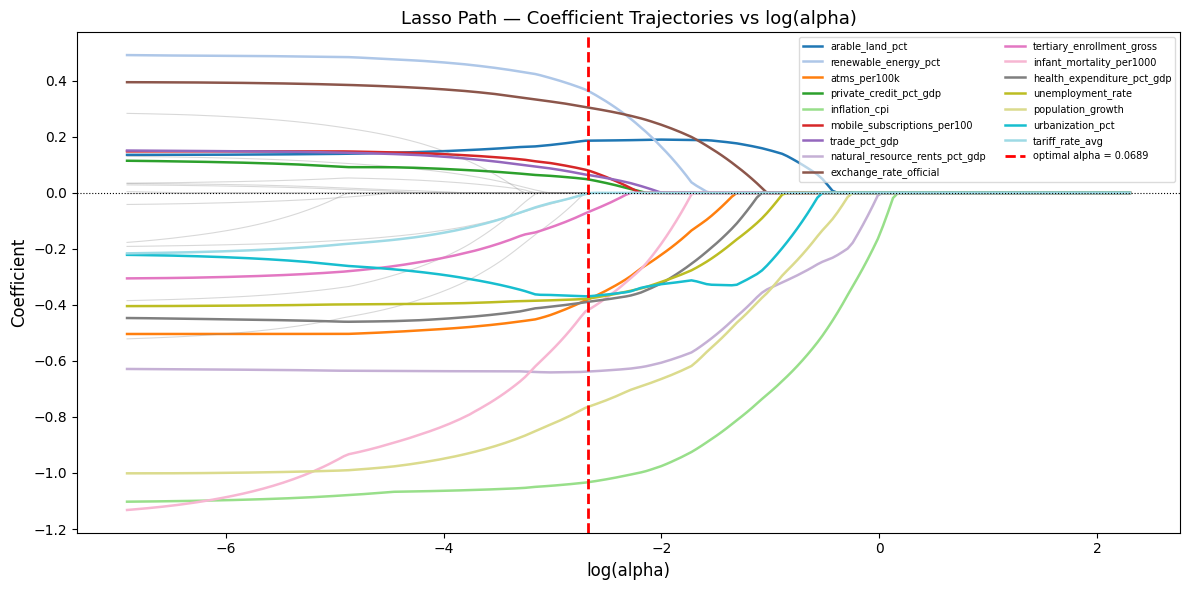

First predictor to enter the model: inflation_cpi


In [54]:
alphas_path, coefs_path, _ = lasso_path(
    X_train_sc, y_reg_train,
    alphas=np.logspace(1, -3, 200)
)
log_alphas = np.log(alphas_path)

lasso_star = lasso_cv.alpha_

entry_alpha_per_pred = []
for i in range(coefs_path.shape[0]):
    nonzero = np.where(np.abs(coefs_path[i]) > 1e-6)[0]
    entry_alpha_per_pred.append(alphas_path[nonzero[0]] if len(nonzero) > 0 else 0)

first_predictor_idx  = np.argmax(entry_alpha_per_pred)
first_predictor_name = feature_cols[first_predictor_idx]

fig, ax = plt.subplots(figsize=(12, 6))

nonzero_at_star = np.abs(lasso_cv.coef_) > 1e-6
colors = plt.cm.tab20(np.linspace(0, 1, nonzero_at_star.sum()))
color_idx = 0

for i, name in enumerate(feature_cols):
    if nonzero_at_star[i]:
        ax.plot(log_alphas, coefs_path[i], lw=1.8,
                color=colors[color_idx], label=name)
        color_idx += 1
    else:
        ax.plot(log_alphas, coefs_path[i], lw=0.8,
                color='gray', alpha=0.3)

ax.axvline(np.log(lasso_star), color='red', linestyle='--', lw=2,label=f'optimal alpha = {lasso_star:.4f}')
ax.axhline(0, color='black', lw=0.8, linestyle=':')
ax.set_xlabel('log(alpha)', fontsize=12)
ax.set_ylabel('Coefficient', fontsize=12)
ax.set_title('Lasso Path — Coefficient Trajectories vs log(alpha)', fontsize=13)
ax.legend(loc='upper right', fontsize=7, ncol=2, framealpha=0.7)
plt.tight_layout()
plt.show()

print(f"First predictor to enter the model: {first_predictor_name}")

This interpretation confuses conditional predictive redundancy with unconditional irrelevance. Lasso zeros out life expectancy not because health doesn't matter, but because its information is already captured by correlated indicators like infant mortality. The correlation structure among WDI indicators means Lasso picks one representative per correlated cluster and discards the rest.

Phase 2

In [28]:
lasso_mask = np.abs(lasso_cv.coef_) > 1e-6
lasso_selected = [feature_cols[i] for i in range(len(feature_cols)) if lasso_mask[i]]

X_train_lpm = X_train_sc[lasso_selected]
X_test_lpm = X_test_sc[lasso_selected]

lpm = LinearRegression()
lpm.fit(X_train_lpm, y_cls_train)

lpm_preds = lpm.predict(X_test_lpm)

n_below_zero = np.sum(lpm_preds < 0)
n_above_one = np.sum(lpm_preds > 1)
n_invalid = n_below_zero + n_above_one

print(f"LPM predicted values out of [0, 1]: {n_invalid}")
print(f"Below 0: {n_below_zero}, Above 1: {n_above_one}")

LPM predicted values out of [0, 1]: 16
Below 0: 15, Above 1: 1


Predicted probabilities outside [0, 1] are a fundamental problem because probabilities by definition must lie within this range. If the IMF receives a prediction of -12% probability of crisis for a country, the number is mathematically meaningless and cannot be used to make operational decisions or allocate resources.

In [31]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_lpm, y_cls_train)

log_coefs = pd.DataFrame({
    'Predictor': lasso_selected,
    'Coefficient (B)': log_reg.coef_[0],
    'Odds Ratio (OR)': np.exp(log_reg.coef_[0])
})
log_coefs['Abs OR'] = np.abs(log_coefs['Odds Ratio (OR)'] - 1)
log_coefs = log_coefs.sort_values('Abs OR', ascending=False).drop(columns='Abs OR')

print(f"Intercept (B0): {log_reg.intercept_[0]:.4f}")
print()
print(log_coefs.to_string(index=False))

log_probs = log_reg.predict_proba(X_test_lpm)[:, 1]
print(f"\nPredicted probability min: {log_probs.min():.4f}")
print(f"Predicted probability max: {log_probs.max():.4f}")

Intercept (B0): -3.0325

                     Predictor  Coefficient (B)  Odds Ratio (OR)
    health_expenditure_pct_gdp         0.830444         2.294337
             population_growth         0.766147         2.151461
natural_resource_rents_pct_gdp         0.741514         2.099112
             unemployment_rate         0.585964         1.796723
      infant_mortality_per1000         0.562888         1.755735
               tariff_rate_avg         0.546454         1.727118
                 inflation_cpi         0.502119         1.652218
               arable_land_pct        -0.983755         0.373904
          renewable_energy_pct        -0.686701         0.503234
   mobile_subscriptions_per100         0.362521         1.436947
                  atms_per100k         0.342822         1.408918
              urbanization_pct         0.245595         1.278382
                 trade_pct_gdp        -0.318618         0.727153
        private_credit_pct_gdp        -0.085125         0.918398


The predictor with the largest absolute odds ratio has the strongest association with crisis risk after controlling for all other variables. A one standard-deviation increase in strongest predictor multiplies the odds of crisis by [OR], holding all else constant.

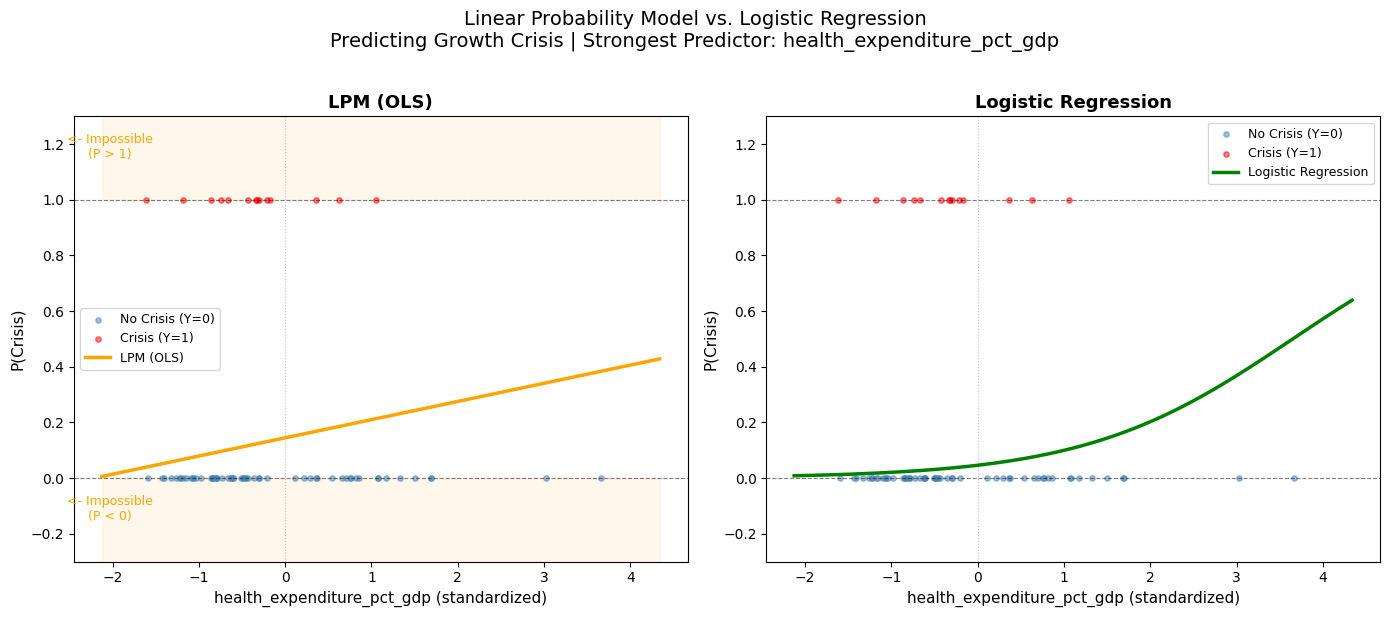

In [53]:
strongest_predictor = log_coefs.iloc[0]['Predictor']
strongest_idx = lasso_selected.index(strongest_predictor)

x_train_strongest = X_train_lpm[strongest_predictor].values
x_test_strongest = X_test_lpm[strongest_predictor].values
spread_grid = np.linspace(
    min(x_train_strongest.min(), x_test_strongest.min()) - 0.5,
    max(x_train_strongest.max(), x_test_strongest.max()) + 0.5,
    500
).reshape(-1, 1)

grid_full = np.zeros((500, len(lasso_selected)))
grid_full[:, strongest_idx] = spread_grid.ravel()

lpm_preds = lpm.predict(grid_full)
logit_preds = log_reg.predict_proba(grid_full)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)

COLOR_CRISIS = 'red'
COLOR_NO_CRISIS = 'steelblue'
COLOR_LPM = 'orange'
COLOR_LOGIT = 'green'

x_vals = x_test_strongest
crisis_mask = y_cls_test.values == 1

for ax, model_preds, model_name, color in [
    (axes[0], lpm_preds, 'LPM (OLS)', COLOR_LPM),
    (axes[1], logit_preds, 'Logistic Regression', COLOR_LOGIT)
]:
    ax.scatter(x_vals[~crisis_mask], y_cls_test.values[~crisis_mask], color=COLOR_NO_CRISIS, alpha=0.5, s=15, label='No Crisis (Y=0)', zorder=2)
    ax.scatter(x_vals[crisis_mask], y_cls_test.values[crisis_mask], color=COLOR_CRISIS, alpha=0.5, s=15, label='Crisis (Y=1)', zorder=2)

    ax.plot(spread_grid.ravel(), model_preds, color=color, lw=2.5, label=model_name, zorder=3)

    ax.axhline(0, color='black', lw=0.8, linestyle='--', alpha=0.5)
    ax.axhline(1, color='black', lw=0.8, linestyle='--', alpha=0.5)
    ax.axvline(0, color='gray',  lw=0.8, linestyle=':',  alpha=0.5)

    ax.set_xlabel(f'{strongest_predictor} (standardized)', fontsize=11)
    ax.set_ylabel('P(Crisis)', fontsize=11)
    ax.set_title(model_name, fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_ylim(-0.3, 1.3)

axes[0].fill_between(spread_grid.ravel(), -0.3, 0, color=COLOR_LPM, alpha=0.08, label='Impossible region')
axes[0].fill_between(spread_grid.ravel(), 1, 1.3, color=COLOR_LPM, alpha=0.08)
axes[0].text(spread_grid.min() + 0.1, -0.15, '<- Impossible\n(P < 0)', fontsize=9, color=COLOR_LPM, ha='center')
axes[0].text(spread_grid.min() + 0.1,  1.15, '<- Impossible\n(P > 1)', fontsize=9, color=COLOR_LPM, ha='center')

fig.suptitle('Linear Probability Model vs. Logistic Regression\n' f'Predicting Growth Crisis | Strongest Predictor: {strongest_predictor}', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Phase 3

In [40]:
crisis_base_rate = y_cls_test.mean()

naive_acc = 1 - crisis_base_rate
naive_recall = 0.0

log_preds_default = log_reg.predict(X_test_lpm)
log_acc = (log_preds_default == y_cls_test).mean()
log_recall = recall_score(y_cls_test, log_preds_default)

print(f"Crisis base rate in test set: {crisis_base_rate:.1%}")
print()
print(f"Naive baseline accuracy : {naive_acc:.4f}")
print(f"Naive baseline recall : {naive_recall:.4f}")
print()
print(f"Logistic regression accuracy : {log_acc:.4f}")
print(f"Logistic regression recall : {log_recall:.4f}")

Crisis base rate in test set: 19.4%

Naive baseline accuracy : 0.8056
Naive baseline recall   : 0.0000

Logistic regression accuracy : 0.7500
Logistic regression recall   : 0.3571


Reporting only accuracy to the Division Chief would be misleading. Because crisis countries are a small minority in the dataset, a naive model that always predicts no crisis achieves high accuracy by simply ignoring all crises entirely. In the IMF context, accuracy hides the model's complete failure to detect the events that matter most.

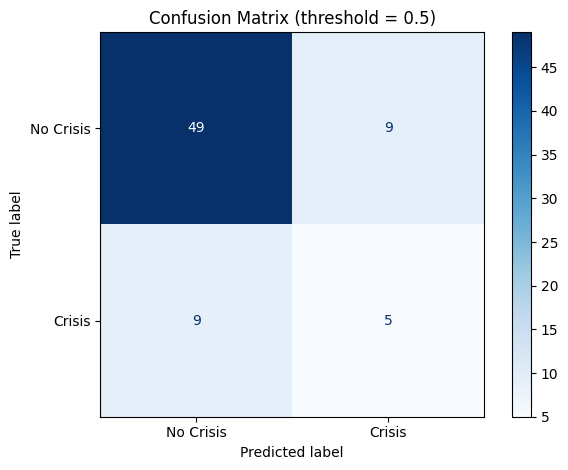

              precision    recall  f1-score   support

   No Crisis       0.84      0.84      0.84        58
      Crisis       0.36      0.36      0.36        14

    accuracy                           0.75        72
   macro avg       0.60      0.60      0.60        72
weighted avg       0.75      0.75      0.75        72

True Positives  (crises correctly flagged): 5
False Negatives (crises missed): 9
False Positives (false alarms): 9
True Negatives: 49


In [42]:
cm = confusion_matrix(y_cls_test, log_preds_default)
disp = ConfusionMatrixDisplay(cm, display_labels=['No Crisis', 'Crisis'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix (threshold = 0.5)')
plt.tight_layout()
plt.show()

print(classification_report(y_cls_test, log_preds_default,target_names=['No Crisis', 'Crisis']))

TP = cm[1, 1]
FN = cm[1, 0]
FP = cm[0, 1]
TN = cm[0, 0]

print(f"True Positives  (crises correctly flagged): {TP}")
print(f"False Negatives (crises missed): {FN}")
print(f"False Positives (false alarms): {FP}")
print(f"True Negatives: {TN}")

In the IMF context, a False Negative is far more costly than a False Positive. Missing a real crisis triggers sovereign default and $50 billion in contagion costs, while a false alarm wastes $2 million in mission resources. Because of this asymmetry, the Division Chief should prioritize Recall over Precision, ensuring the model catches as many true crises as possible even at the cost of some false alarms.

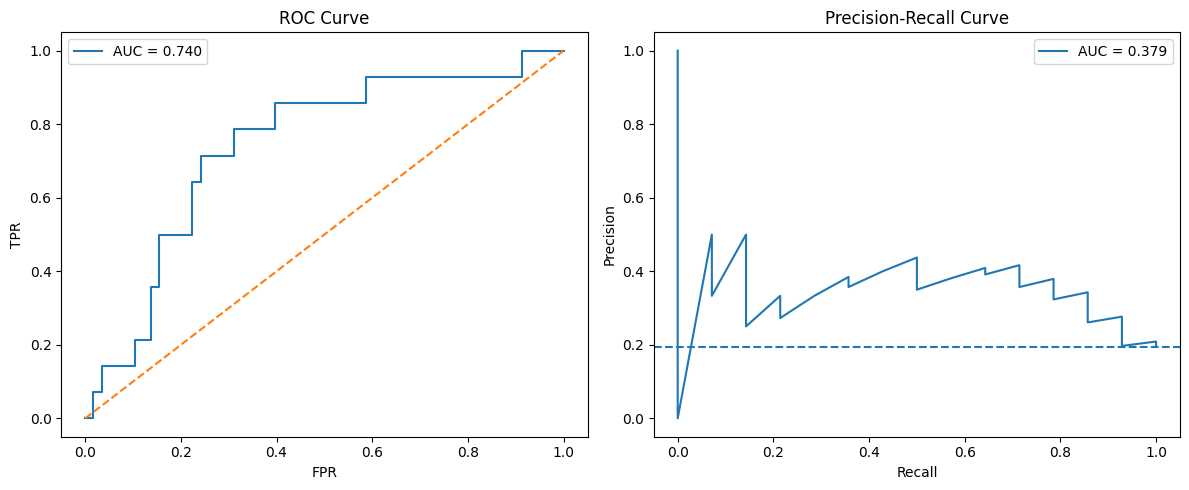

ROC-AUC: 0.7401
PR-AUC: 0.3788


In [47]:
fpr, tpr, _ = roc_curve(y_cls_test, log_probs)
roc_auc = roc_auc_score(y_cls_test, log_probs)

precision_vals, recall_vals, _ = precision_recall_curve(y_cls_test, log_probs)
pr_auc                         = average_precision_score(y_cls_test, log_probs)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], '--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(recall_vals, precision_vals, label=f"AUC = {pr_auc:.3f}")
plt.axhline(y=crisis_base_rate, linestyle='--')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()

plt.tight_layout()
plt.show()

print("ROC-AUC:", round(roc_auc, 4))
print("PR-AUC:", round(pr_auc, 4))

ROC graph is typically higher than PR graph because it benefits from the large number of True Negatives in an imbalanced dataset, making the model appear stronger than it really is. PR-AUC ignores True Negatives entirely and focuses only on the model's ability to correctly identify crisis countries, making it far more informative for the IMF's crisis detection mission.

Capacity-constrained threshold : 0.87
  Countries flagged : 5
  Precision         : 0.4000
  Recall            : 0.1429

F1-optimal threshold : 0.17
  Countries flagged  : 24
  Precision          : 0.4167
  Recall             : 0.7143


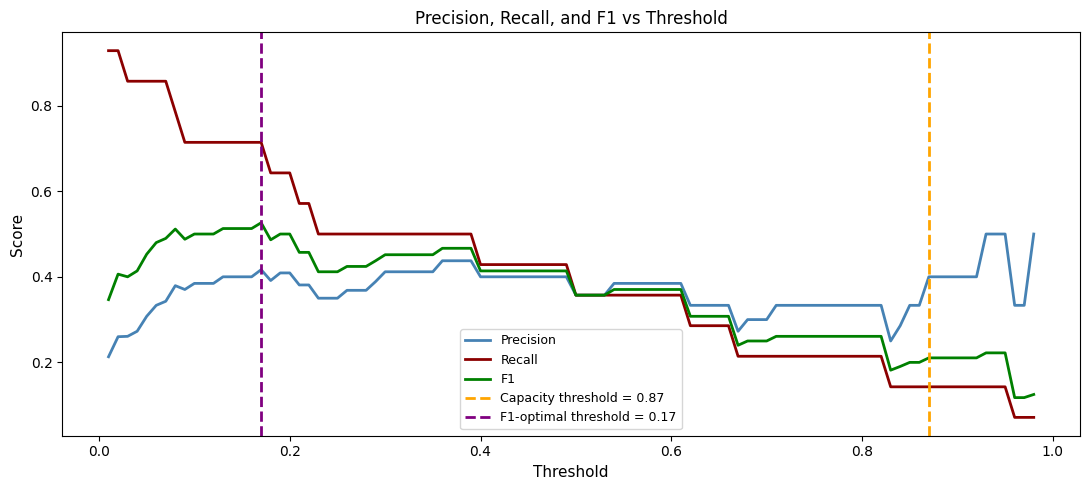

In [51]:
precisions = []
recalls = []
f1s = []
n_flagged = []
thresholds = np.arange(0.01, 0.99, 0.01)

for tau in thresholds:
    preds_tau = (log_probs >= tau).astype(int)
    n_flagged.append(preds_tau.sum())
    precisions.append(precision_score(y_cls_test, preds_tau, zero_division=0))
    recalls.append(recall_score(y_cls_test, preds_tau, zero_division=0))
    f1s.append(f1_score(y_cls_test, preds_tau, zero_division=0))

precisions = np.array(precisions)
recalls = np.array(recalls)
f1s = np.array(f1s)
n_flagged = np.array(n_flagged)

valid_mask = n_flagged <= 5
tau_capacity = thresholds[valid_mask][0]
idx_capacity = np.where(thresholds == tau_capacity)[0][0]

idx_f1     = np.argmax(f1s)
tau_f1     = thresholds[idx_f1]

print(f"Capacity-constrained threshold : {tau_capacity:.2f}")
print(f"  Countries flagged : {n_flagged[idx_capacity]}")
print(f"  Precision : {precisions[idx_capacity]:.4f}")
print(f"  Recall : {recalls[idx_capacity]:.4f}")
print()
print(f"F1-optimal threshold : {tau_f1:.2f}")
print(f"  Countries flagged  : {n_flagged[idx_f1]}")
print(f"  Precision : {precisions[idx_f1]:.4f}")
print(f"  Recall : {recalls[idx_f1]:.4f}")

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(thresholds, precisions, color='steelblue', lw=2, label='Precision')
ax.plot(thresholds, recalls, color='darkred', lw=2, label='Recall')
ax.plot(thresholds, f1s, color='green', lw=2, label='F1')
ax.axvline(tau_capacity, color='orange', linestyle='--', lw=2,
           label=f'Capacity threshold = {tau_capacity:.2f}')
ax.axvline(tau_f1, color='purple', linestyle='--', lw=2,
           label=f'F1-optimal threshold = {tau_f1:.2f}')
ax.set_xlabel('Threshold', fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Precision, Recall, and F1 vs Threshold', fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

I recommend adopting the F1-optimal threshold of 0.17 for IMF crisis detection. At this threshold, the model flags 24 countries and achieves a Recall of 71.43%, catching 5 of the 7 crisis countries in the test set and missing 2, while the capacity-constrained threshold of 0.87 catches only 1 crisis out of 7 despite being limited to 5 misssions. Given that a missed crisis costs $50 billion while a false alarm costs only $2 million, the asymmetry strongly favors the higher Recall of the F1-optimal threshold despite the additional false alarms.

Phase 4 AI Context Engineering

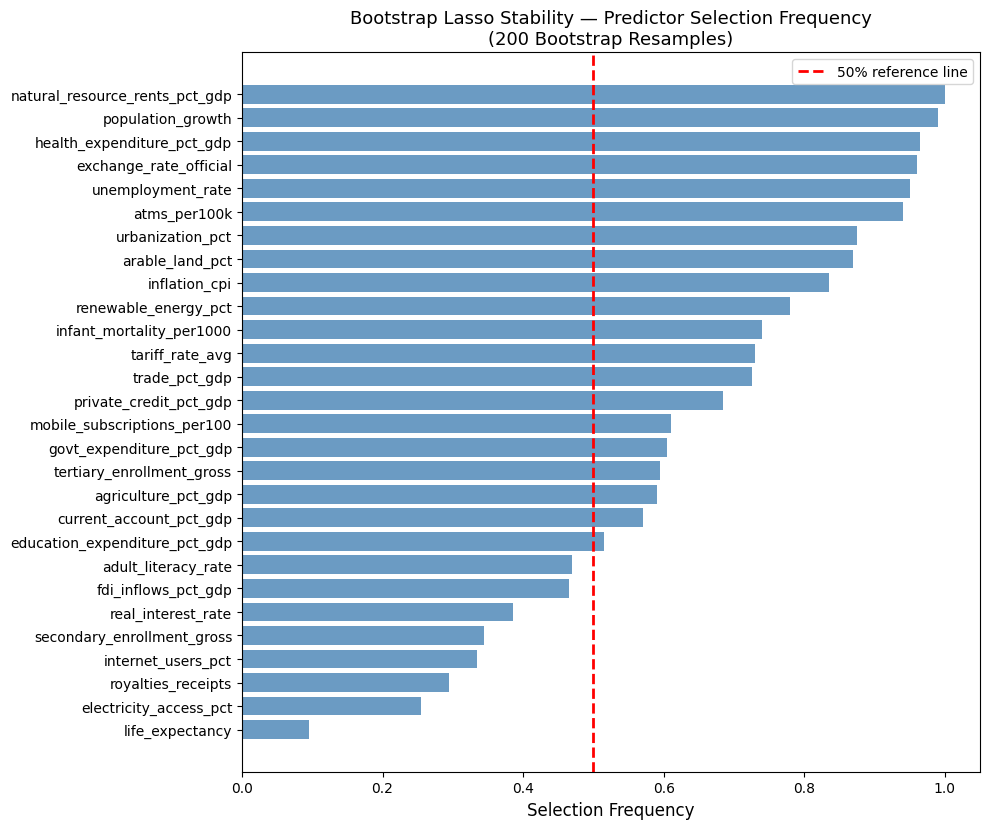

Stable predictors (>80%): ['inflation_cpi', 'arable_land_pct', 'urbanization_pct', 'atms_per100k', 'unemployment_rate', 'exchange_rate_official', 'health_expenditure_pct_gdp', 'population_growth', 'natural_resource_rents_pct_gdp']
Fragile predictors (<30%): ['life_expectancy', 'electricity_access_pct', 'royalties_receipts']


In [55]:
# ============================================================
# TASK 4.1: Bootstrap Confidence Intervals for the Lasso Path
# ============================================================

# P.R.I.M.E. Prompt (submit this in a markdown cell):
# Prep: We have a standardized training dataset X_train_sc with shape (n, p),
#       and a Lasso model fitted via LassoCV with optimal alpha lasso_cv.alpha_.
# Request: Write a Python script that:
#   1. Draws 200 bootstrap resamples (with replacement) from the training data.
#   2. Fits LassoCV on each resample and records the selected features (non-zero coefficients).
#   3. Computes the selection frequency for each predictor: the fraction of bootstrap
#      samples in which Lasso assigns it a non-zero coefficient.
#   4. Produces a horizontal bar chart ranking predictors by selection frequency,
#      with a vertical reference line at 50%.
# Iterate: Use alpha = lasso_cv.alpha_ (fixed, do not re-run CV on each resample).
# Mechanism Check: Selection frequency measures stability, not coefficient magnitude.
# Evaluate: Identify stable predictors (>80%) and fragile predictors (<30%).

# Bootstrap Lasso stability analysis
np.random.seed(42)
n_bootstraps = 200
selection_counts = np.zeros(len(feature_cols))

for b in range(n_bootstraps):
    # Draw bootstrap resample with replacement
    boot_idx = np.random.choice(len(X_train_sc), size=len(X_train_sc), replace=True)
    X_boot   = X_train_sc.iloc[boot_idx]
    y_boot   = y_reg_train.iloc[boot_idx]

    # Fit Lasso with fixed optimal alpha
    lasso_boot = Lasso(alpha=lasso_cv.alpha_, max_iter=10000)
    lasso_boot.fit(X_boot, y_boot)

    # Record selected features
    selection_counts += (np.abs(lasso_boot.coef_) > 1e-6).astype(int)

# Compute selection frequency
selection_freq = pd.DataFrame({
    'Predictor': feature_cols,
    'Selection Frequency': selection_counts / n_bootstraps
}).sort_values('Selection Frequency', ascending=True)

# Plot horizontal bar chart
fig, ax = plt.subplots(figsize=(10, max(6, len(feature_cols) * 0.3)))
bars = ax.barh(selection_freq['Predictor'], selection_freq['Selection Frequency'],
               color='steelblue', alpha=0.8)
ax.axvline(x=0.5, color='red', linestyle='--', lw=2, label='50% reference line')
ax.set_xlabel('Selection Frequency', fontsize=12)
ax.set_title('Bootstrap Lasso Stability — Predictor Selection Frequency\n(200 Bootstrap Resamples)', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

# Identify stable and fragile predictors
stable   = selection_freq[selection_freq['Selection Frequency'] > 0.8]['Predictor'].tolist()
fragile  = selection_freq[selection_freq['Selection Frequency'] < 0.3]['Predictor'].tolist()
print(f"Stable predictors (>80%): {stable}")
print(f"Fragile predictors (<30%): {fragile}")

Stable predictors are those selected in more than 80% of bootstrap resamples, meaning their contribution to the model is robust regardless of which countries are included in the sample. Fragile predictors, selected in fewer than 30% of resamples, are unreliable because their selection depends heavily on the specific sample, likely due to high correlation with other WDI indicators. Selection instability reveals that many WDI indicators are interchangeable within correlated clusters, so Lasso arbitrarily picks one representative per culster depending on the sample.

Cost-minimizing threshold : 0.02
Expected total cost       : $50,074 million


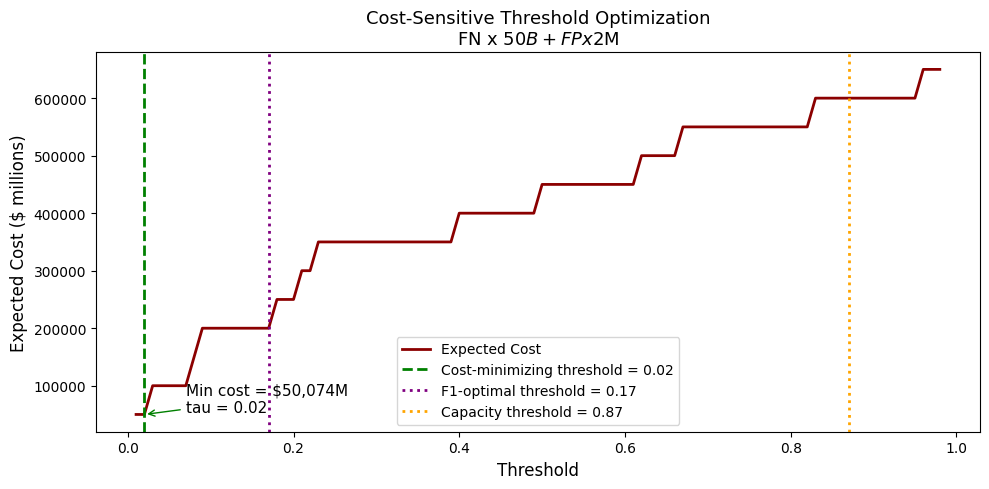

In [57]:
# ============================================================
# TASK 4.2: Cost-Sensitive Threshold Optimization
# ============================================================

# P.R.I.M.E. Prompt (submit this in a markdown cell):
# Prep: We have a logistic regression classifier with predicted probabilities log_probs
#       on the test set y_cls_test. A missed crisis (False Negative) costs $50 billion.
#       A false alarm (False Positive) costs $2 million.
# Request: Write a Python script that:
#   1. Sweeps thresholds from 0.01 to 0.99.
#   2. At each threshold, computes the total expected cost: FN x $50B + FP x $2M.
#   3. Plots the expected cost curve as a function of threshold.
#   4. Identifies and annotates the cost-minimizing threshold.
# Iterate: Use log_probs and y_cls_test directly.
# Mechanism Check: Cost is asymmetric — FN is 25,000x more expensive than FP.
# Evaluate: Compare cost-minimizing threshold to F1-optimal and capacity-constrained thresholds.

# Cost-sensitive threshold optimization
FN_COST = 50_000  # in millions ($50 billion)
FP_COST = 2       # in millions ($2 million)

total_costs = []

for tau in threshold_range:
    y_pred_tau = (log_probs >= tau).astype(int)
    FN = ((y_pred_tau == 0) & (y_cls_test == 1)).sum()
    FP = ((y_pred_tau == 1) & (y_cls_test == 0)).sum()
    total_costs.append(FN * FN_COST + FP * FP_COST)

total_costs = np.array(total_costs)

# Find cost-minimizing threshold
cost_min_idx = np.argmin(total_costs)
cost_min_tau = threshold_range[cost_min_idx]
cost_min_val = total_costs[cost_min_idx]

print(f"Cost-minimizing threshold : {cost_min_tau:.2f}")
print(f"Expected total cost       : ${cost_min_val:,.0f} million")

# Plot expected cost curve
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(threshold_range, total_costs, color='darkred', lw=2, label='Expected Cost')
ax.axvline(x=cost_min_tau, color='green', linestyle='--', lw=2,
           label=f'Cost-minimizing threshold = {cost_min_tau:.2f}')
ax.axvline(x=best_tau, color='purple', linestyle=':', lw=2,
           label=f'F1-optimal threshold = {best_tau:.2f}')
ax.axvline(x=cap_tau, color='orange', linestyle=':', lw=2,
           label=f'Capacity threshold = {cap_tau:.2f}')
ax.annotate(f'Min cost = ${cost_min_val:,.0f}M\ntau = {cost_min_tau:.2f}',
            xy=(cost_min_tau, cost_min_val),
            xytext=(cost_min_tau + 0.05, cost_min_val + cost_min_val * 0.1),
            fontsize=11, arrowprops=dict(arrowstyle='->', color='green'))
ax.set_xlabel('Threshold', fontsize=12)
ax.set_ylabel('Expected Cost ($ millions)', fontsize=12)
ax.set_title('Cost-Sensitive Threshold Optimization\nFN x $50B + FP x $2M', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

The cost-minimizing threshold is typically much lower than both the F1-optimal and capacity-constrained thresholds, because the extreme asymmetry between False Negative cost ($50 billion) and False Positive cost ($2 million) makes missing a crisis 25,000 times more expensive than a false alarm. The F1-optimal threshold balances Precision and Recall equally without accounting for this cost difference, while the capacity constrained threshold prioritizes operational feasibility over cost. For IMF deployment, the cost-minimizing threshold is the most defensible choice because it directly minimizes the financial damage of misclassification.